In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

# Observing the Dataset

In [4]:
train.head()
# test.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-06-28 17:20:21,2023-06-28 16:34:45,1.0,2.14,1.0,N,120,9,Credit Card,2.5,7.165589,0.0,1.0,20.64,2.5,0.0
1,0,2023-06-29 23:05:01,2023-06-29 22:01:35,1.0,2.70,1.0,N,15,215,Credit Card,3.5,6.067401,0.0,1.0,25.55,2.5,0.0
2,1,2023-06-30 10:19:31,2023-06-30 11:13:10,1.0,1.15,1.0,N,167,223,Credit Card,0.0,4.111547,0.0,1.0,17.64,2.5,0.0
3,0,2023-06-29 13:23:09,2023-06-29 14:20:01,1.0,0.40,1.0,N,128,239,Credit Card,2.5,6.411079,0.0,1.0,12.80,2.5,0.0
4,1,2023-06-29 22:03:32,2023-06-29 22:22:22,3.0,1.10,1.0,N,203,52,Credit Card,1.0,4.769377,0.0,1.0,18.00,2.5,0.0


# Data Statistics

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175000 entries, 0 to 174999
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               175000 non-null  int64  
 1   tpep_pickup_datetime   175000 non-null  object 
 2   tpep_dropoff_datetime  175000 non-null  object 
 3   passenger_count        168923 non-null  float64
 4   trip_distance          175000 non-null  float64
 5   RatecodeID             168923 non-null  float64
 6   store_and_fwd_flag     168923 non-null  object 
 7   PULocationID           175000 non-null  int64  
 8   DOLocationID           175000 non-null  int64  
 9   payment_type           175000 non-null  object 
 10  extra                  175000 non-null  float64
 11  tip_amount             175000 non-null  float64
 12  tolls_amount           175000 non-null  float64
 13  improvement_surcharge  175000 non-null  float64
 14  total_amount           175000 non-nu

In [ ]:
(train[train['VendorID']>90]) & (train[train['congestion_surcharge']<0])

In [6]:
train.isna().sum()

VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          6077
trip_distance               0
RatecodeID               6077
store_and_fwd_flag       6077
PULocationID                0
DOLocationID                0
payment_type                0
extra                       0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
total_amount                0
congestion_surcharge     6077
Airport_fee              6077
dtype: int64

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               50000 non-null  int64  
 1   tpep_pickup_datetime   50000 non-null  object 
 2   tpep_dropoff_datetime  50000 non-null  object 
 3   passenger_count        48221 non-null  float64
 4   trip_distance          50000 non-null  float64
 5   RatecodeID             48221 non-null  float64
 6   store_and_fwd_flag     48221 non-null  object 
 7   PULocationID           50000 non-null  int64  
 8   DOLocationID           50000 non-null  int64  
 9   payment_type           50000 non-null  object 
 10  extra                  50000 non-null  float64
 11  tip_amount             50000 non-null  float64
 12  tolls_amount           50000 non-null  float64
 13  improvement_surcharge  50000 non-null  float64
 14  congestion_surcharge   48221 non-null  float64
 15  Ai

In [8]:
test.isna().sum()

VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          1779
trip_distance               0
RatecodeID               1779
store_and_fwd_flag       1779
PULocationID                0
DOLocationID                0
payment_type                0
extra                       0
tip_amount                  0
tolls_amount                0
improvement_surcharge       0
congestion_surcharge     1779
Airport_fee              1779
dtype: int64

In [9]:
train.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,175000.000000,168923.000000,175000.000000,168923.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,168923.000000,168923.000000
mean,0.728377,1.357678,5.145930,1.518307,132.710349,132.701429,1.932143,6.127497,0.646816,0.979689,29.633901,2.246971,0.158825
std,0.445606,0.891283,394.971052,6.514678,76.148799,76.192493,1.948497,4.610834,2.328274,0.198775,25.425206,0.819216,0.511968
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-7.500000,0.000079,-29.300000,-1.000000,-576.750000,-2.500000,-1.750000
25%,0.000000,1.000000,1.080000,1.000000,67.000000,67.000000,0.000000,3.473321,0.000000,1.000000,16.300000,2.500000,0.000000
50%,1.000000,1.000000,1.840000,1.000000,133.000000,133.000000,1.000000,5.286217,0.000000,1.000000,21.450000,2.500000,0.000000
75%,1.000000,1.000000,3.610000,1.000000,199.000000,199.000000,2.500000,7.502746,0.000000,1.000000,31.800000,2.500000,0.000000
max,2.000000,9.000000,135182.060000,99.000000,264.000000,264.000000,11.750000,484.876151,80.000000,1.000000,587.250000,2.500000,1.750000


In [10]:
test.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee
count,50000.000000,48221.000000,50000.000000,48221.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,48221.000000,48221.000000
mean,0.730280,1.358309,3.999013,1.567014,132.208160,132.559300,1.918050,6.107765,0.615867,0.981354,2.255345,0.152133
std,0.444584,0.879948,78.958759,6.875115,76.483766,76.410602,1.938568,4.408572,2.289421,0.190203,0.803190,0.502866
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-7.500000,0.000409,-23.000000,-1.000000,-2.500000,-1.750000
25%,0.000000,1.000000,1.090000,1.000000,66.000000,67.000000,0.000000,3.464018,0.000000,1.000000,2.500000,0.000000
50%,1.000000,1.000000,1.850000,1.000000,132.000000,133.000000,1.000000,5.271687,0.000000,1.000000,2.500000,0.000000
75%,1.000000,1.000000,3.600000,1.000000,199.000000,199.000000,2.500000,7.504048,0.000000,1.000000,2.500000,0.000000
max,2.000000,8.000000,17624.430000,99.000000,264.000000,264.000000,11.750000,96.551343,47.750000,1.000000,2.500000,1.750000


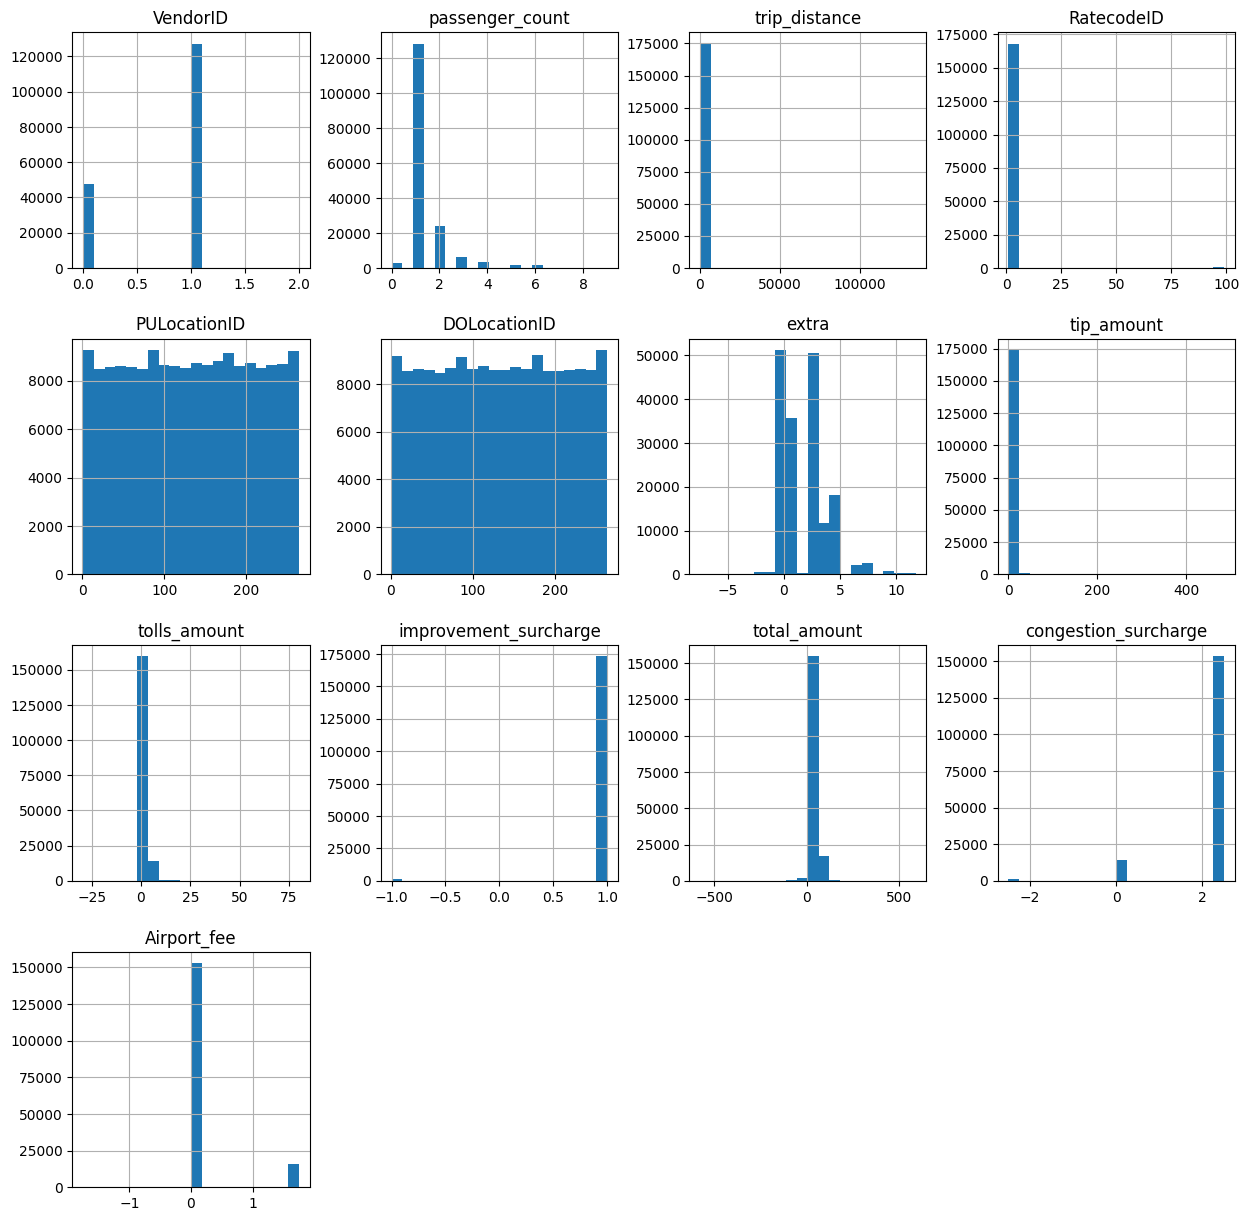

In [11]:
# display histogram
import matplotlib.pyplot as plt
import seaborn as sns

# display histogram
train.hist(bins=20,figsize=(15,15))
plt.show()

## Initial Correlation Matrix 

<AxesSubplot:>

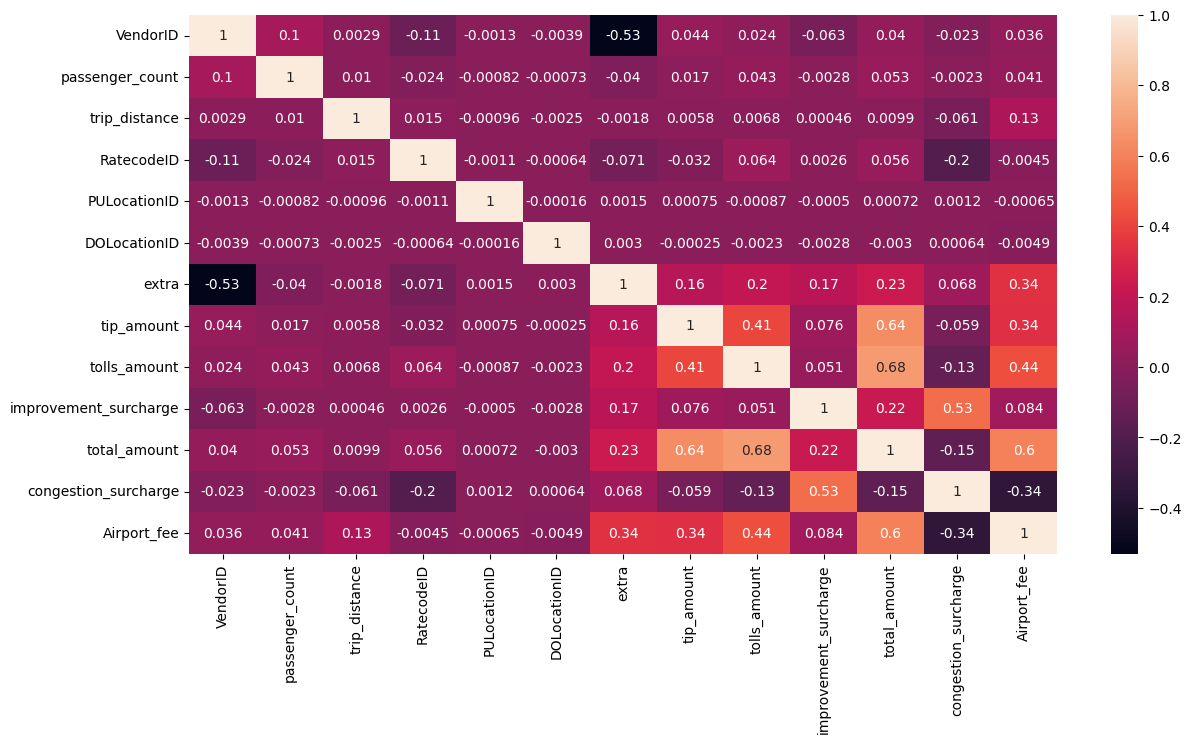

In [12]:
num_features=train.drop(columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'payment_type'])
corr_matrix=num_features.corr()
plt.figure(figsize=(14,7))
sns.heatmap(corr_matrix, annot=True)

# Data Visualization

# Data Preprocessing

## Feature Extraction 
### Date Time
- We can get date, day, hour from the datetime feature.

#### tpep_pickup_datetime, tpep_dropoff_datetime:
- These have some entries anomalous. tpep_dropoff_datetime should be greater than tpep_pickup_datetime(w.r.t. time), but in some observation this is false, hence we need to correct these observations.

In [13]:
for index, row in train.iterrows():
    if row['tpep_dropoff_datetime'] < row['tpep_pickup_datetime']:
        # Swap values
        temp = row['tpep_pickup_datetime']
        train.at[index, 'tpep_pickup_datetime'] = row['tpep_dropoff_datetime']
        train.at[index, 'tpep_dropoff_datetime'] = temp


train['tpep_pickup_datetime'] = pd.to_datetime(train['tpep_pickup_datetime'])
train['tpep_dropoff_datetime'] = pd.to_datetime(train['tpep_dropoff_datetime'])

# Create new features
train['pickup_hour'] = train['tpep_pickup_datetime'].dt.hour  # Extract the hour of pickup
train['dropoff_hour'] = train['tpep_dropoff_datetime'].dt.hour  # Extract the hour of dropoff
train['pickup_dayofweek'] = train['tpep_pickup_datetime'].dt.dayofweek  # Extract the day of the week (0 = Monday, 6 = Sunday)
train['trip_duration_minutes'] = (train['tpep_dropoff_datetime'] - train['tpep_pickup_datetime']).dt.total_seconds() / 60 # Calculate trip duration in minutes



for index, row in test.iterrows():
    if row['tpep_dropoff_datetime'] < row['tpep_pickup_datetime']:
        # Swap values
        temp = row['tpep_pickup_datetime']
        test.at[index, 'tpep_pickup_datetime'] = row['tpep_dropoff_datetime']
        test.at[index, 'tpep_dropoff_datetime'] = temp


test['tpep_pickup_datetime'] = pd.to_datetime(test['tpep_pickup_datetime'])
test['tpep_dropoff_datetime'] = pd.to_datetime(test['tpep_dropoff_datetime'])

# Create new features
test['pickup_hour'] = test['tpep_pickup_datetime'].dt.hour  # Extract the hour of pickup
test['dropoff_hour'] = test['tpep_dropoff_datetime'].dt.hour  # Extract the hour of dropoff
test['pickup_dayofweek'] = test['tpep_pickup_datetime'].dt.dayofweek  # Extract the day of the week (0 = Monday, 6 = Sunday)
test['trip_duration_minutes'] = (test['tpep_dropoff_datetime'] - test['tpep_pickup_datetime']).dt.total_seconds() / 60 # Calculate trip duration in minutes

## Data Cleaning

We can observe that there are missing values in store_and_fwd_flag 

In [14]:
train['store_and_fwd_flag'].unique()
# test['store_and_fwd_flag'].unique()

array(['N', nan, 'Y'], dtype=object)

Here we can observe that one of the payment types is "unknown" which is similar to np.nan /null values, so lets impute these too

In [15]:
(train['payment_type'].value_counts()/175000)*100
# (test['payment_type'].value_counts()/50000)*100

Credit Card    77.289714
Cash           17.223429
Wallet          3.472571
unknown         1.333143
UPI             0.681143
Name: payment_type, dtype: float64

In [16]:
train['RatecodeID'].unique()
# test['RatecodeID'].unique()

array([ 1., 99.,  3., nan,  2.,  5.,  4.])

In [17]:
(train['RatecodeID'].value_counts()/175000)*100
# (test['RatecodeID'].value_counts()/50000)*100

1.0     90.658286
2.0      4.179429
5.0      0.592000
99.0     0.427429
3.0      0.415429
4.0      0.254857
Name: RatecodeID, dtype: float64

It seems that 99 may not be an actual RatecodeID, as it is too far away from the other values, hence we should drop these values(make them np.nan) and then impute them later

In [18]:
train['RatecodeID'] = train['RatecodeID'].replace(99.0, np.nan)
test['RatecodeID'] = test['RatecodeID'].replace(99.0, np.nan)

### Outliers: 
#### Trip Distance

In [19]:
train['trip_distance'].describe()

count    175000.000000
mean          5.145930
std         394.971052
min           0.000000
25%           1.080000
50%           1.840000
75%           3.610000
max      135182.060000
Name: trip_distance, dtype: float64

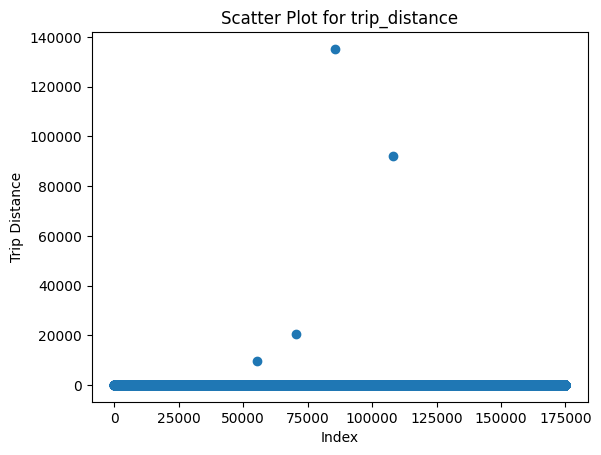

In [20]:
plt.scatter(range(len(train['trip_distance'])), train['trip_distance'])

plt.xlabel('Index')
plt.ylabel('Trip Distance')
plt.title('Scatter Plot for trip_distance')

plt.show()

##### Potential outlier in trip_distance


|   Index   | Trip Distance |
|-----------|---------------|
|   7742    |     71.04     |
|  34594    |     71.07     |
| 157351    |     71.94     |
| 147364    |     73.23     |
| 151945    |     79.55     |
|  77615    |     81.10     |
|  22872    |     83.69     |
| 104495    |     83.69     |
|  48974    |     84.16     |
| 153336    |    104.09     |
|  59599    |    132.10     |
| 165589    |    143.35     |
|  55147    |   9673.69     |
|  70458    |  20314.00     |
| 107988    | 92292.43      |
|  85525    |135182.06      |


These are some of the last values of the sorted list of the **trip_distance**  feature, here we can clearly see that the values beyond 150 are impractical. so we need to drop or **impute these values with the mean** of this feature.


In [21]:
sorted_distances = train['trip_distance'].sort_values()
print(sorted_distances)

66842          0.00
68328          0.00
5283           0.00
68343          0.00
94605          0.00
            ...    
165589       143.35
55147       9673.69
70458      20314.00
107988     92292.43
85525     135182.06
Name: trip_distance, Length: 175000, dtype: float64


In [22]:
# Replace values greater than 150 with np.nan
train['trip_distance'] = np.where(train['trip_distance'] > 150, np.nan, train['trip_distance'])

# avoided this as the test score decreased, overfitting could be a reason for this

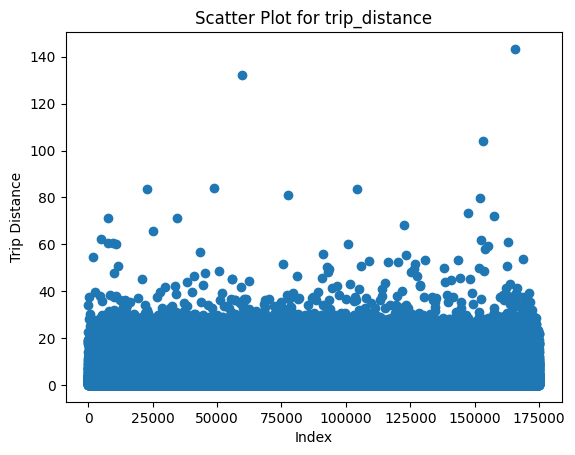

In [23]:
plt.scatter(range(len(train['trip_distance'])), train['trip_distance'])

plt.xlabel('Index')
plt.ylabel('Trip Distance')
plt.title('Scatter Plot for trip_distance')

plt.show()

In [24]:
np.isnan(train['trip_distance']).any()

True

#### Passenger Count

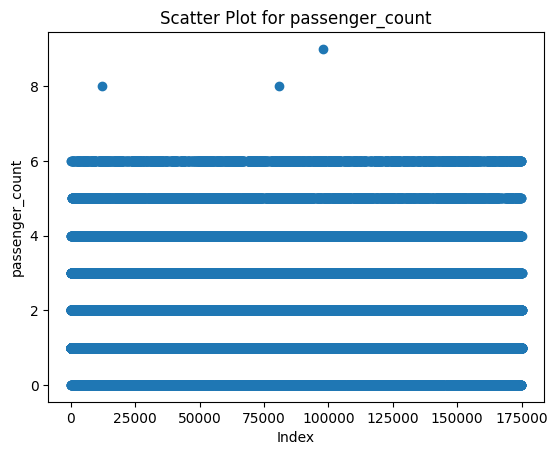

In [25]:
plt.scatter(range(len(train['passenger_count'])), train['passenger_count'])

plt.xlabel('Index')
plt.ylabel('passenger_count')
plt.title('Scatter Plot for passenger_count')

plt.show()

In [26]:
train['passenger_count'].describe()

count    168923.000000
mean          1.357678
std           0.891283
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           9.000000
Name: passenger_count, dtype: float64

In [27]:
# # rows where passenger_count is 0 ensuring total_amount is not 0
# train[(train['passenger_count'] == 0) & (train['total_amount'] != 0)].info()

In [28]:
# # Replace 0 with np.nan as zero passengers seems impractical
# train['passenger_count'] = np.where((train['passenger_count'] == 0) & (train['total_amount'] != 0), np.nan, train['passenger_count'])

# # avoided this as the test score decreased, overfitting could be a reason for this

In [29]:
numCols = list(train.select_dtypes("number").columns)
catCols = list(train.select_dtypes(exclude = "number").columns)
catCols,numCols

(['tpep_pickup_datetime',
  'tpep_dropoff_datetime',
  'store_and_fwd_flag',
  'payment_type'],
 ['VendorID',
  'passenger_count',
  'trip_distance',
  'RatecodeID',
  'PULocationID',
  'DOLocationID',
  'extra',
  'tip_amount',
  'tolls_amount',
  'improvement_surcharge',
  'total_amount',
  'congestion_surcharge',
  'Airport_fee',
  'pickup_hour',
  'dropoff_hour',
  'pickup_dayofweek',
  'trip_duration_minutes'])

## Imputation

In [30]:
# need to drop total_amount as we don't pass target variable during preprocessing
special_train=train.drop(columns=['total_amount'])

In [31]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [32]:
numeric_features1=['VendorID',
  'passenger_count',
  'RatecodeID',
  'PULocationID',
  'DOLocationID',
  'extra',
  'tip_amount',
  'tolls_amount',
  'improvement_surcharge',
  'congestion_surcharge',
  'Airport_fee',
  'pickup_hour',
  'dropoff_hour',
  'pickup_dayofweek',
  'trip_duration_minutes']

numeric_features2=['trip_distance']

# categorical_features=['store_and_fwd_flag','payment_type']

In [33]:
# Imputer and encoder for 'store_and_fwd_flag'
store_fwd_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# Imputer and encoder for 'payment_type'
payment_type_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='unknown')),
    # ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ('encoder', OrdinalEncoder())
])

In [34]:
numeric_transformer1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
      
])
numeric_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
      
])

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('store_fwd', store_fwd_transformer, ['store_and_fwd_flag']),
        ('payment_type', payment_type_transformer, ['payment_type']),
        ('num1', numeric_transformer1, numeric_features1),
        ('num2', numeric_transformer2, numeric_features2),
    ])

In [36]:
scaler = StandardScaler()

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                             ('scaler', scaler)])

In [37]:
X_train_transformed = pipeline.fit_transform(special_train)

# Get the feature names for numerical features
numeric_feature_names1 = list(train[numeric_features1].columns)
numeric_feature_names2 = list(train[numeric_features2].columns)

# Get the feature names for 'store_and_fwd_flag'
store_fwd_feature_name = ['store_and_fwd_flag']

# Get the feature names for 'payment_type' after one-hot encoding
# payment_type_feature_names = list(preprocessor.named_transformers_['payment_type']
#                                   .named_steps['encoder']
#                                   .get_feature_names_out(['payment_type']))
payment_type_feature_names = ['payment_type']


# Combine all feature names
all_feature_names = store_fwd_feature_name + payment_type_feature_names + numeric_feature_names1 + numeric_feature_names2

# Create a DataFrame with the transformed data and feature names
X_train_processed = pd.DataFrame(X_train_transformed, columns=all_feature_names)

In [38]:
target_column = train['total_amount']

# Concatenating the preprocessed features and the target variable to visualize the correlation matrix
train = pd.concat([X_train_processed, target_column], axis=1)


In [39]:
# Transform the test data
X_test_transformed = pipeline.transform(test)

# Get the feature names for 'payment_type' after one-hot encoding
# payment_type_feature_names_test = list(preprocessor.named_transformers_['payment_type']
#                                        .named_steps['encoder']
#                                        .get_feature_names_out(['payment_type']))
payment_type_feature_names_test = ['payment_type']


# Combine all feature names for the test set
all_feature_names_test = store_fwd_feature_name + payment_type_feature_names_test + numeric_feature_names1 + numeric_feature_names2

# Create a DataFrame with the transformed test data and feature names
test = pd.DataFrame(X_test_transformed, columns=all_feature_names_test)


In [40]:
train.info()
# test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175000 entries, 0 to 174999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   store_and_fwd_flag     175000 non-null  float64
 1   payment_type           175000 non-null  float64
 2   VendorID               175000 non-null  float64
 3   passenger_count        175000 non-null  float64
 4   RatecodeID             175000 non-null  float64
 5   PULocationID           175000 non-null  float64
 6   DOLocationID           175000 non-null  float64
 7   extra                  175000 non-null  float64
 8   tip_amount             175000 non-null  float64
 9   tolls_amount           175000 non-null  float64
 10  improvement_surcharge  175000 non-null  float64
 11  congestion_surcharge   175000 non-null  float64
 12  Airport_fee            175000 non-null  float64
 13  pickup_hour            175000 non-null  float64
 14  dropoff_hour           175000 non-nu

# Data Visualization

array([[<AxesSubplot:xlabel='total_amount', ylabel='total_amount'>,
        <AxesSubplot:xlabel='extra', ylabel='total_amount'>,
        <AxesSubplot:xlabel='tip_amount', ylabel='total_amount'>,
        <AxesSubplot:xlabel='tolls_amount', ylabel='total_amount'>,
        <AxesSubplot:xlabel='improvement_surcharge', ylabel='total_amount'>,
        <AxesSubplot:xlabel='Airport_fee', ylabel='total_amount'>],
       [<AxesSubplot:xlabel='total_amount', ylabel='extra'>,
        <AxesSubplot:xlabel='extra', ylabel='extra'>,
        <AxesSubplot:xlabel='tip_amount', ylabel='extra'>,
        <AxesSubplot:xlabel='tolls_amount', ylabel='extra'>,
        <AxesSubplot:xlabel='improvement_surcharge', ylabel='extra'>,
        <AxesSubplot:xlabel='Airport_fee', ylabel='extra'>],
       [<AxesSubplot:xlabel='total_amount', ylabel='tip_amount'>,
        <AxesSubplot:xlabel='extra', ylabel='tip_amount'>,
        <AxesSubplot:xlabel='tip_amount', ylabel='tip_amount'>,
        <AxesSubplot:xlabel='tolls_am

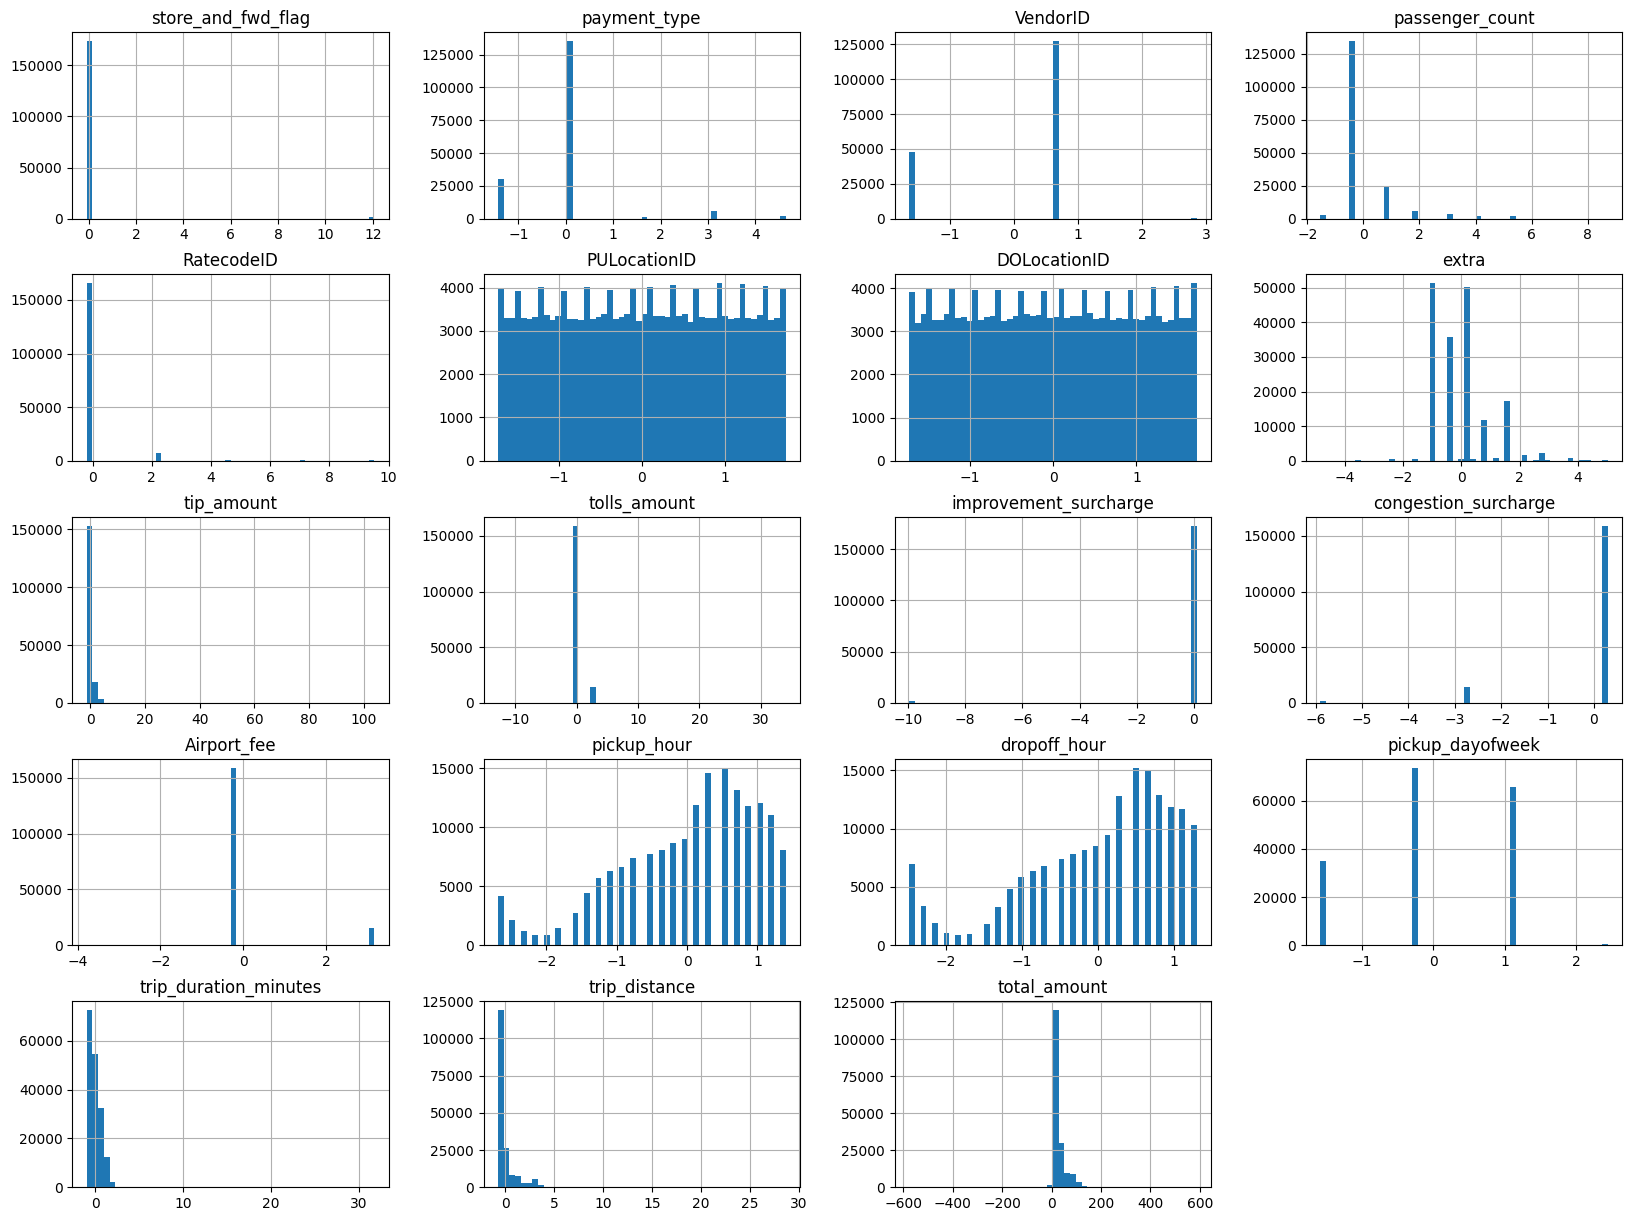

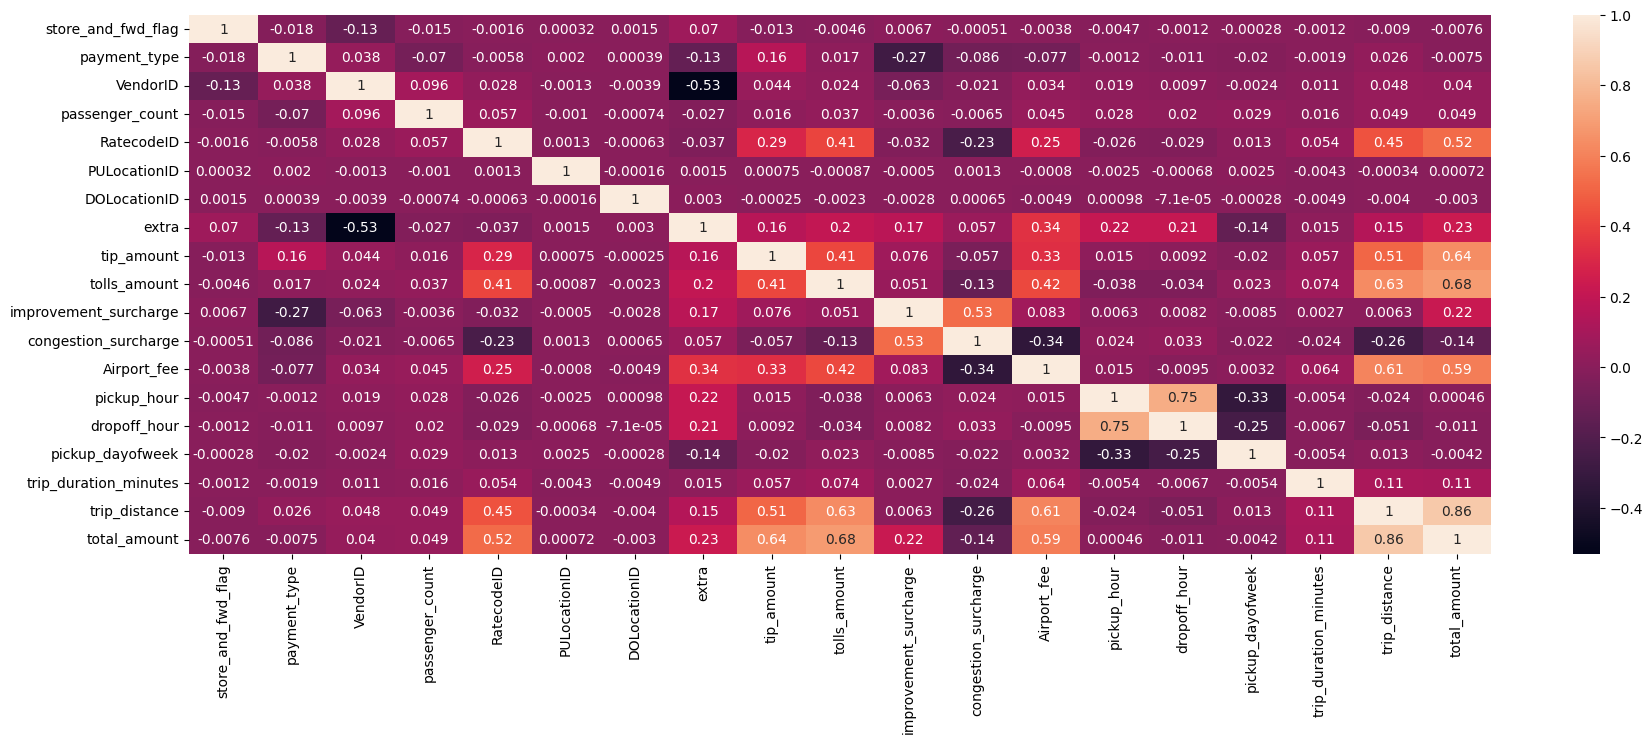

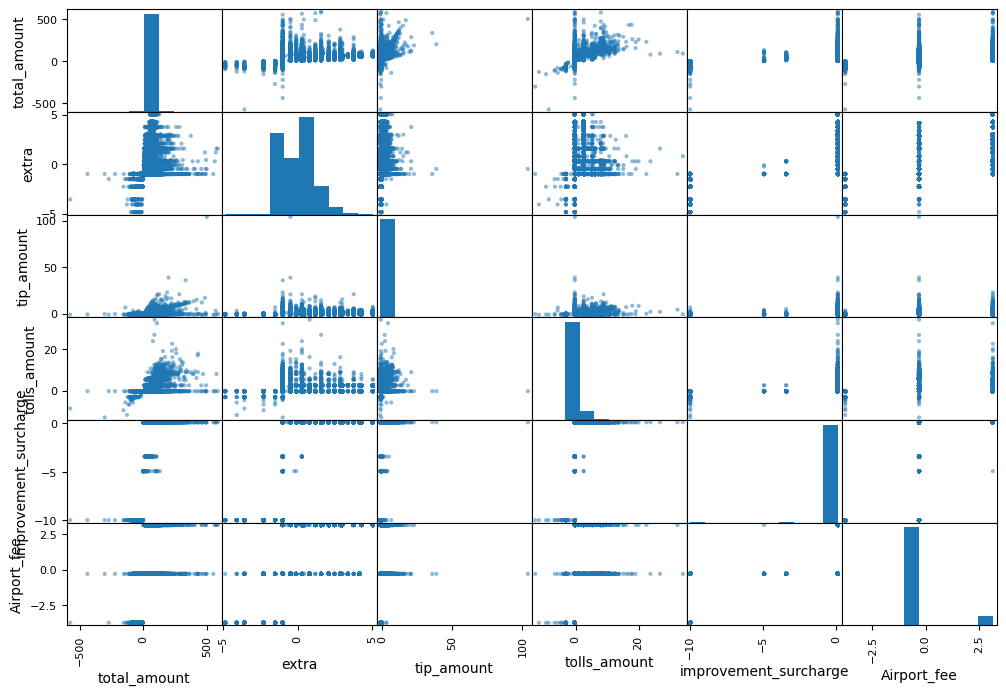

In [41]:
train.hist(bins=50, figsize=(20, 15))

# corelation matrix 
corr_matrix=train.corr()
plt.figure(figsize=(21,7))
sns.heatmap(corr_matrix, annot=True)

# scatter plots of important features
from pandas.plotting import scatter_matrix
attributes = ['total_amount','extra', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'Airport_fee']
scatter_matrix(train[attributes], figsize=(12,8))

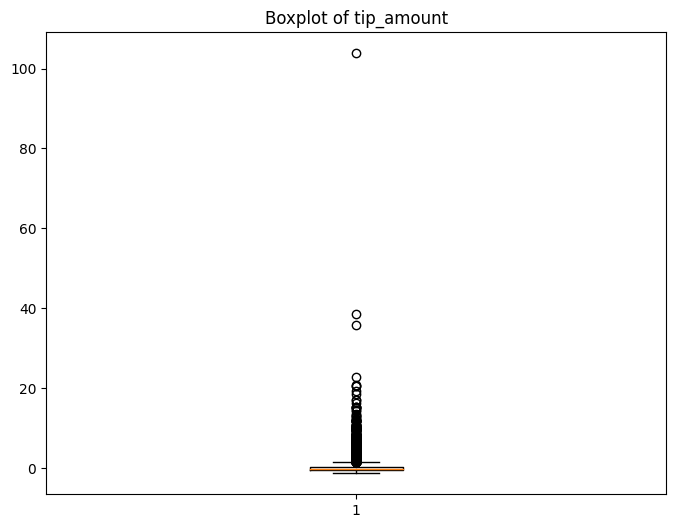

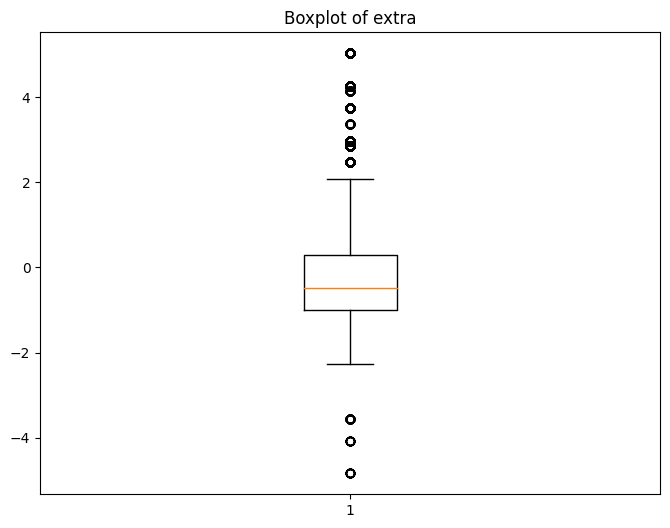

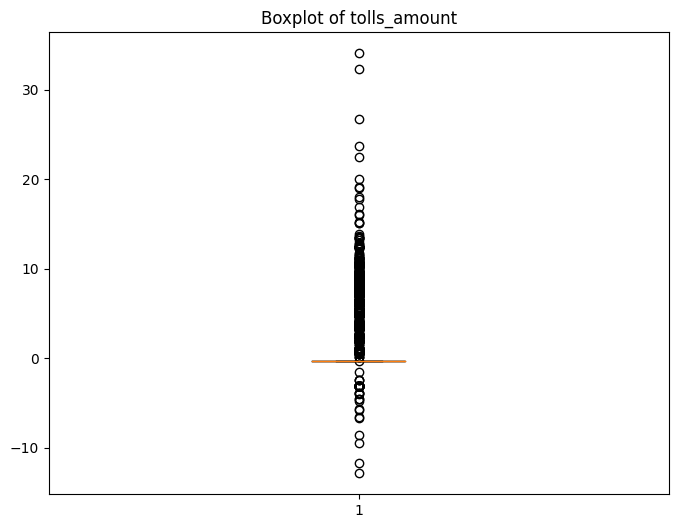

In [42]:
plt.figure(figsize=(8, 6))
plt.boxplot(train['tip_amount'])
plt.title("Boxplot of tip_amount")

plt.figure(figsize=(8, 6))
plt.boxplot(train['extra'])
plt.title("Boxplot of extra")

plt.figure(figsize=(8, 6))
plt.boxplot(train['tolls_amount'])
plt.title("Boxplot of tolls_amount")

plt.show()

In [43]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175000 entries, 0 to 174999
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   store_and_fwd_flag     175000 non-null  float64
 1   payment_type           175000 non-null  float64
 2   VendorID               175000 non-null  float64
 3   passenger_count        175000 non-null  float64
 4   RatecodeID             175000 non-null  float64
 5   PULocationID           175000 non-null  float64
 6   DOLocationID           175000 non-null  float64
 7   extra                  175000 non-null  float64
 8   tip_amount             175000 non-null  float64
 9   tolls_amount           175000 non-null  float64
 10  improvement_surcharge  175000 non-null  float64
 11  congestion_surcharge   175000 non-null  float64
 12  Airport_fee            175000 non-null  float64
 13  pickup_hour            175000 non-null  float64
 14  dropoff_hour           175000 non-nu

# Train-Val-Split

In [44]:
# X=train[['RatecodeID', 'Airport_fee', 'extra', 'tip_amount', 'tolls_amount','improvement_surcharge','trip_duration_minutes']]
# X=train[['VendorID','passenger_count','trip_distance', 'RatecodeID', 'extra', 'tip_amount', 'tolls_amount','improvement_surcharge', 'Airport_fee', 'trip_duration_minutes']]
# X=train.drop(columns=['total_amount', 'payment_type_Cash','payment_type_Credit Card', 'payment_type_UPI', 'payment_type_Wallet', 'payment_type_unknown'])
# X=train.drop(columns=['store_and_fwd_flag', 'congestion_surcharge', 'PULocationID', 'DOLocationID', 'total_amount', 'payment_type_Cash','payment_type_Credit Card', 'payment_type_UPI', 'payment_type_Wallet'])

# X=train.drop(columns=['total_amount','VendorID'])

X=train.drop(columns=['total_amount'])
y=train['total_amount']

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training

# LinearRegression
- Base Model

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr=LinearRegression()
lr.fit(X_train,y_train)

lr.score(X_train,y_train),lr.score(X_val,y_val)

(0.8730959941935827, 0.8902326001920837)

# Lasso

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('lasso', Lasso()),
])

param_grid = {'lasso__alpha': [0.01, 0.1, 1.0, 10.0]}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
best_model.score(X_train, y_train),best_model.score(X_val,y_val)

(0.8730920617470357, 0.8902347043629716)

# GradientBoostingRegressor

In [48]:
# Best Parameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=10, learning_rate=0.01, random_state=42)

gbr.fit(X_train,y_train)
gbr.score(X_train, y_train),gbr.score(X_val, y_val)

(0.9745216444134296, 0.9467277201778052)

# DecisionTreeRegressor
- Hyperparameter tuning was done offline as it is too time-consuming.

In [49]:
# param_grid = {
#     'max_depth': [10, 20, 30],
#     'min_samples_split': [2, 5, 7, 8, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(max_depth=10, random_state= 42, min_samples_split=7)

dtr.fit(X_train,y_train)
dtr.score(X_train, y_train),dtr.score(X_val, y_val)

(0.9516270078477964, 0.9378078876616707)

# RandomForestRegressor
- Hyperparameter tuning was done offline as it is too time-consuming.

In [51]:
# param_grid = {
#     'n_estimators': [100, 300],
#     'max_depth': [10, 30],
#     'min_samples_split': [2, 7],
#     'min_samples_leaf': [1]
# }

# Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 300}

In [52]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=300, max_depth=30, random_state= 42, min_samples_split=7, min_samples_leaf=1)

rfr.fit(X_train,y_train)
rfr.score(X_train, y_train),rfr.score(X_val, y_val)

(0.9848710026955432, 0.9607310608400679)

# ExtraTreesRegressor
- Best Model

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, 30],
    'min_samples_split': [2, 7],
    'min_samples_leaf': [1]
}


grid_search = GridSearchCV(etr, param_grid, cv=5, scoring='r2') 
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_model = ExtraTreesRegressor(**best_params)
best_model.fit(X_train, y_train)

train_score = best_model.score(X_train, y_train)
val_score = best_model.score(X_val,y_val)

train_score,val_score

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 300}


(0.989652067844569, 0.9635110232899813)

In [57]:
# Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 300}

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor

etr = ExtraTreesRegressor(n_estimators=300, max_depth=30, min_samples_leaf=1, min_samples_split=7, random_state=42)

etr.fit(X_train,y_train)
etr.score(X_train, y_train),etr.score(X_val, y_val)

(0.9897214585835676, 0.9635782150178889)

# Submission

In [ ]:
y_test_pred=etr.predict(test)
y_test_pred

array([34.23227013, 25.74528779, 16.47123558, ..., 21.55251043,
       35.23573719, 17.34958186])

In [ ]:
submission = pd.DataFrame(columns = ["ID", "total_amount"])
submission["ID"] = [i for i in range(1, len(y_test_pred)+1)]
submission["total_amount"] = y_test_pred
submission.to_csv('submission.csv', index=False)

In [ ]:
submission.head()

,ID,total_amount
0,1,34.232270
1,2,25.745288
2,3,16.471236
3,4,15.023030
4,5,25.470467


In [ ]:
len(submission)

50000